# PHYS 771 - Homework 2 <br><font color='blue'>Fitting Real TESS Lightcurves </font>
###### Last Updated: June 22, 2026 by Prof. Lisa Dang
***

<font color="green"> **Example to-do**
- search the exoplanet WASP-43b on https://exofop.ipac.caltech.edu/tess/
- use the TESS Web Visibility Tool on the website to identify TESS sectors that observed that planet
- Use the lightcurves of one the sectors that observed the planet your chose</font>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lombscargle

## Loading TESS data

Text(0.5, 0, 'Time (BTJD)')

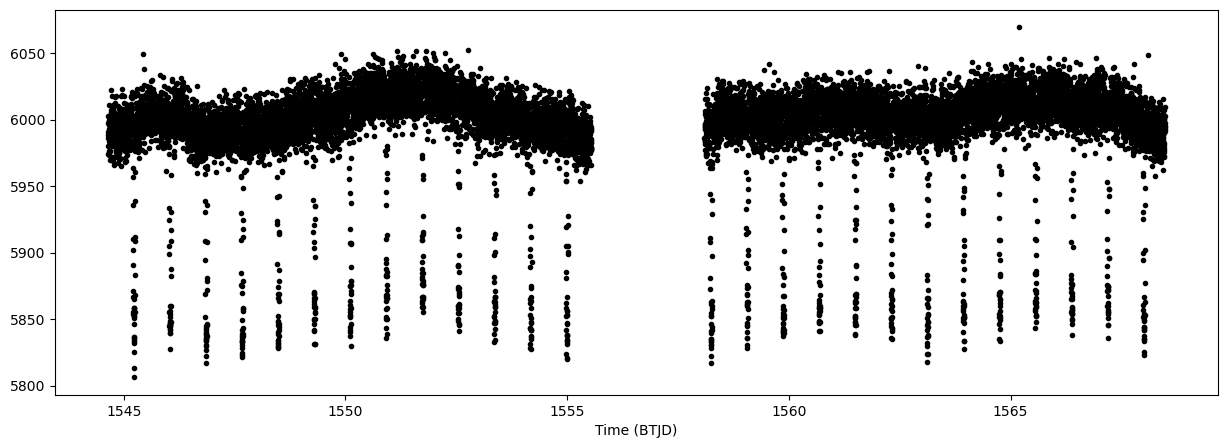

In [ ]:
# dataset information
tic = "TIC 111111111" # replace with the actual TIC ID
sector = 1

# searching for the desired dataset
sr = lk.search_lightcurve(tic, mission="TESS", sector=sector)
# download the data and storing in variable lc
lc = sr.download()

# removing bad data (NaN values) 
lc = lc.remove_nans()
lc = lc[lc.quality == 0]
lc = lc[~lc.flux.mask]

# extracting time, flux, and exposure time
time = np.asarray(lc.time.value, dtype=float)
flux = np.asarray(lc.flux.value, dtype=float)

# remove any remaining NaNs
mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

plt.figure(figsize=(15,5))
plt.plot(time, flux, "k.")
plt.xlabel("Time (BTJD)")
# plt.axvline(2338.7)
# plt.axvline(2342.1)
# print(2342.1-2338.7)